# 📊 Notebook 04 — Exploratory Data Analysis
**Healthcare RAG-Powered Medical Q&A Assistant**
**eyouth × DEPI | Microsoft Machine Learning Track | 2026**

---

### 🎯 Objectives
- Analyse the labelled dataset (`pubmedqa_labelled.csv`)
- Produce the 4 required visualisations:
  1. Category frequency bar chart
  2. Question & answer length histograms
  3. Top-20 medical terms wordcloud
  4. Average output length per category
- Flag any skewed categories
- Generate `reports/eda_report.md` with dynamic content

### 📋 Deliverables
- `notebooks/03_eda.ipynb`
- `reports/eda_report.md`
- All figures saved in `reports/figures/`

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from datetime import datetime
import re
import os
import numpy as np

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Output directories
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

print("✅ Libraries loaded | Directories ready")

✅ Libraries loaded | Directories ready


## 2. Load Labelled Dataset

In [2]:
data_path = "../data/processed/pubmedqa_labelled.csv"
df = pd.read_csv(data_path)

print(f"✅ Dataset loaded: {data_path}")
print(f"   Shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")

# Verify expected columns
assert 'category' in df.columns, "Missing 'category' column"
assert 'question' in df.columns, "Missing 'question' column"
assert 'answer' in df.columns, "Missing 'answer' column"
assert 'context' in df.columns, "Missing 'context' column"

df.head(3)

✅ Dataset loaded: ../data/processed/pubmedqa_labelled.csv
   Shape: (10000, 4)
   Columns: ['question', 'context', 'answer', 'category']


,question,context,answer,category
0,Is naturopathy as effective as conventional th...,Although the use of alternative medicine in th...,Naturopathy appears to be an effective alterna...,Treatment
1,Can randomised trials rely on existing electro...,"To estimate the feasibility, utility and resou...",Routine data have the potential to support hea...,Treatment
2,Is laparoscopic radical prostatectomy better t...,To compare morbidity in two groups of patients...,The results of our non-randomized study show t...,Treatment


## 3. Create Length Features

In [3]:
df['question_length'] = df['question'].fillna('').str.split().str.len()
df['context_length'] = df['context'].fillna('').str.split().str.len()
df['answer_length'] = df['answer'].fillna('').str.split().str.len()

length_stats = df[['question_length', 'context_length', 'answer_length']].describe()
print("📊 Text Length Statistics (word count)")
print(length_stats)

# Save for report
length_stats.to_csv('../reports/eda_length_stats.csv')

📊 Text Length Statistics (word count)
       question_length  context_length  answer_length
count     10000.000000    10000.000000   10000.000000
mean         13.321600      197.258300      42.314400
std           4.563185       57.567308      20.411409
min           3.000000       26.000000       6.000000
25%          10.000000      161.000000      28.000000
50%          13.000000      195.000000      39.000000
75%          16.000000      227.000000      52.000000
max          45.000000      606.000000     313.000000


## 4. Visualisation 1 — Category Frequency Bar Chart

**M1 KPI: All 6 categories present with ≥ 1% representation**

C:\Users\Matrix\AppData\Local\Temp\ipykernel_26460\668708679.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax, palette='husl')


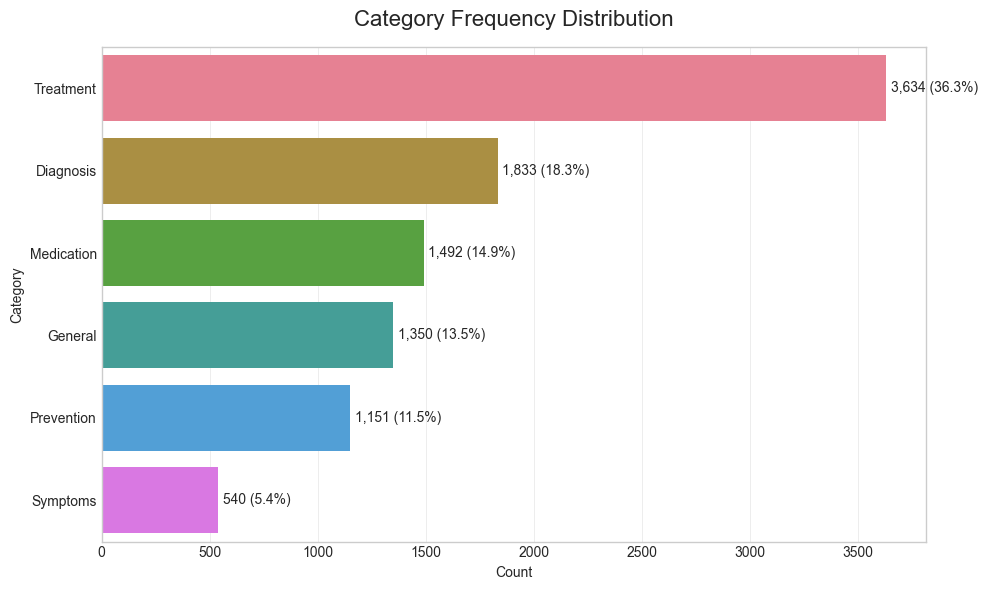


📊 Category Skew Analysis:
  Treatment        3,634 ( 36.3%)
  Diagnosis        1,833 ( 18.3%)
  Medication       1,492 ( 14.9%)
  General          1,350 ( 13.5%)
  Prevention       1,151 ( 11.5%)
  Symptoms           540 (  5.4%)


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

cat_counts = df['category'].value_counts()
total = len(df)

sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax, palette='husl')
ax.set_title('Category Frequency Distribution', fontsize=16, pad=15)
ax.set_xlabel('Count')
ax.set_ylabel('Category')

# Add count + percentage labels
for i, (count, cat) in enumerate(zip(cat_counts.values, cat_counts.index)):
    pct = count / total * 100
    ax.text(count + 20, i, f'{count:,} ({pct:.1f}%)', va='center')

# Flag skewed categories
for i, (count, cat) in enumerate(zip(cat_counts.values, cat_counts.index)):
    pct = count / total * 100
    if pct < 2.0:
        ax.text(count + 20, i + 0.25, '⚠️ low', va='center', fontsize=8, color='red')

plt.tight_layout()
plt.savefig('../reports/figures/01_category_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

# Print skew analysis
print("\n📊 Category Skew Analysis:")
for cat, count in cat_counts.items():
    pct = count / total * 100
    flag = ' ⚠️  BORDERLINE' if pct < 2.0 else ''
    print(f"  {cat:<15} {count:>6,} ({pct:>5.1f}%){flag}")

## 5. Visualisation 2 — Question & Answer Length Histograms

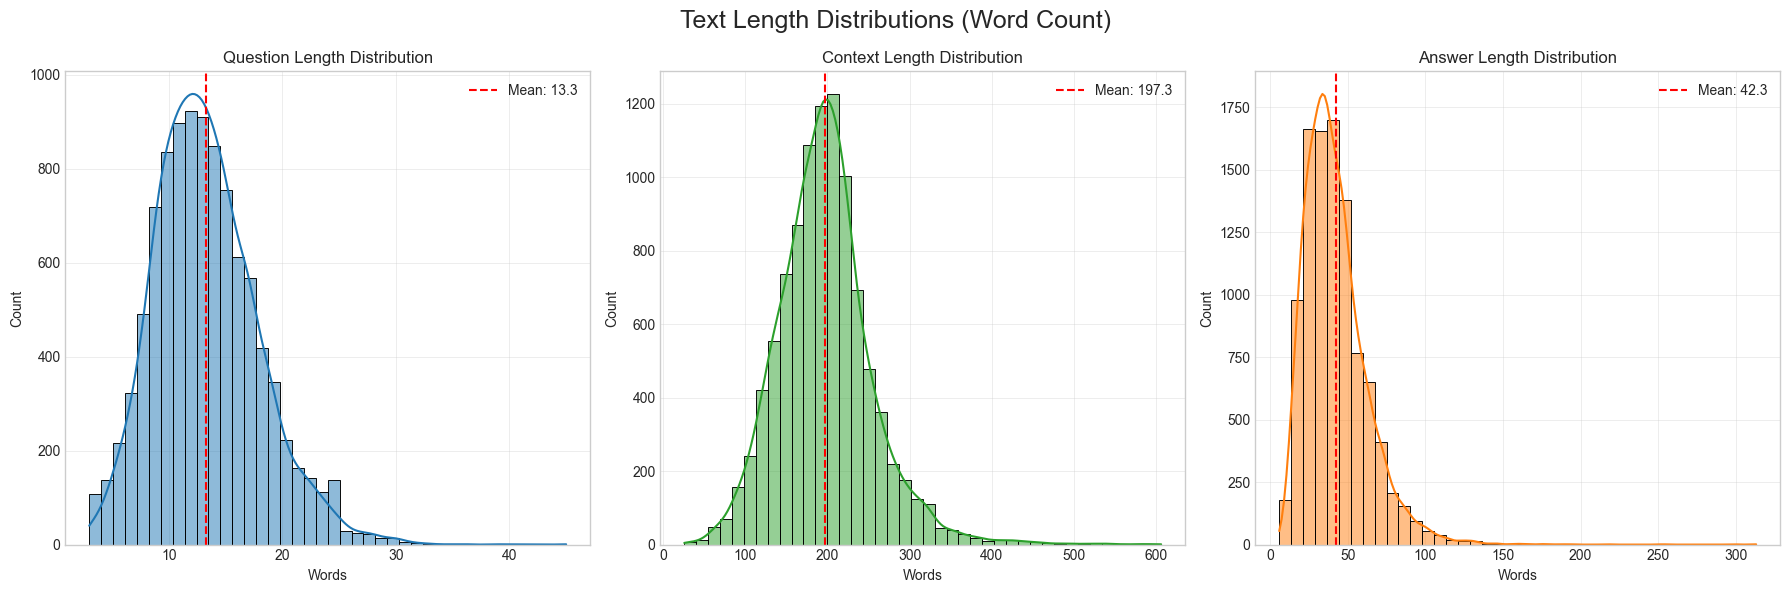

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(df['question_length'], bins=40, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Question Length Distribution')
axes[0].set_xlabel('Words')
axes[0].axvline(df['question_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['question_length'].mean():.1f}")
axes[0].legend()

sns.histplot(df['context_length'], bins=40, kde=True, ax=axes[1], color='#2ca02c')
axes[1].set_title('Context Length Distribution')
axes[1].set_xlabel('Words')
axes[1].axvline(df['context_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['context_length'].mean():.1f}")
axes[1].legend()

sns.histplot(df['answer_length'], bins=40, kde=True, ax=axes[2], color='#ff7f0e')
axes[2].set_title('Answer Length Distribution')
axes[2].set_xlabel('Words')
axes[2].axvline(df['answer_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['answer_length'].mean():.1f}")
axes[2].legend()

plt.suptitle('Text Length Distributions (Word Count)', fontsize=18)
plt.tight_layout()
plt.savefig('../reports/figures/02_length_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Visualisation 3 — Top-20 Medical Terms Wordcloud

**Plan requirement: "top-20 medical terms wordcloud"**

C:\Users\Matrix\AppData\Local\Temp\ipykernel_26460\2916429573.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(terms), ax=axes[1], palette='viridis')


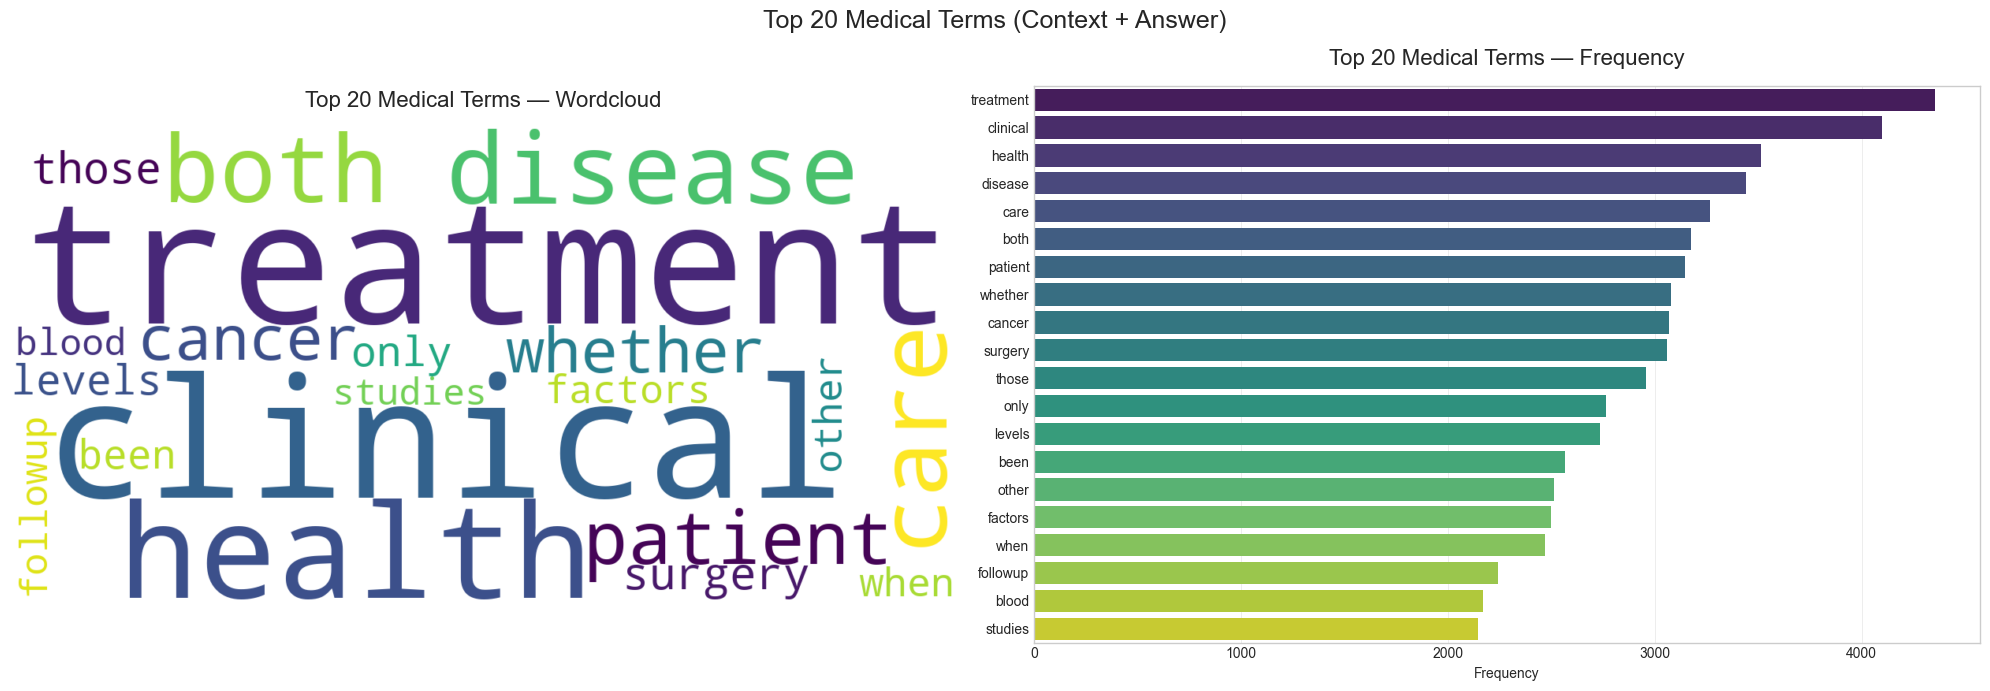


📊 Top 20 Medical Terms:
  treatment                  4,354
  clinical                   4,097
  health                     3,511
  disease                    3,440
  care                       3,265
  both                       3,176
  patient                    3,145
  whether                    3,078
  cancer                     3,068
  surgery                    3,060
  those                      2,959
  only                       2,762
  levels                     2,733
  been                       2,567
  other                      2,511
  factors                    2,499
  when                       2,468
  followup                   2,242
  blood                      2,168
  studies                    2,143


In [6]:
# Extract meaningful medical terms from context + answer
STOP_WORDS = {
    'the', 'and', 'of', 'to', 'in', 'a', 'is', 'for', 'with', 'on', 'by',
    'as', 'this', 'that', 'are', 'was', 'were', 'be', 'at', 'from', 'or',
    'an', 'it', 'not', 'but', 'have', 'has', 'had', 'which', 'we', 'you',
    'they', 'their', 'there', 'these', 'more', 'less', 'than', 'also',
    'may', 'can', 'could', 'would', 'one', 'two', 'three', 'four', 'five',
    'used', 'using', 'use', 'results', 'result', 'shown', 'showed', 'data',
    'analysis', 'based', 'however', 'although', 'while', 'since', 'after',
    'before', 'during', 'between', 'among', 'within', 'without', 'versus',
    'compared', 'patients', 'study', 'group', 'groups', 'significant',
    'significantly', 'observed', 'found', 'associated', 'total', 'mean',
    'respectively', 'number', 'performed', 'received', 'reported',
    'included', 'years', 'months', 'days', 'cases', 'control', 'women',
    'men', 'children', 'age', 'time', 'period', 'rate', 'level', 'high',
    'low', 'increased', 'decreased', 'higher', 'lower', 'similar',
    'difference', 'differences', 'effect', 'effects', 'risk'
}


def extract_medical_terms(text):
    text = re.sub(r'[^a-z\s]', '', str(text).lower())
    words = [w for w in text.split() if w not in STOP_WORDS and len(w) > 3]
    return words


all_words = []
for txt in (df['context'].fillna('') + ' ' + df['answer'].fillna('')):
    all_words.extend(extract_medical_terms(txt))

word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

# Create frequency dict for wordcloud
top_20_dict = dict(top_20)

# Generate wordcloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=20,
    prefer_horizontal=0.7
).generate_from_frequencies(top_20_dict)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Left: Wordcloud
axes[0].imshow(wc, interpolation='bilinear')
axes[0].set_title('Top 20 Medical Terms — Wordcloud', fontsize=16, pad=15)
axes[0].axis('off')

# Right: Bar chart (for exact counts)
terms, counts = zip(*top_20)
sns.barplot(x=list(counts), y=list(terms), ax=axes[1], palette='viridis')
axes[1].set_title('Top 20 Medical Terms — Frequency', fontsize=16, pad=15)
axes[1].set_xlabel('Frequency')

plt.suptitle('Top 20 Medical Terms (Context + Answer)', fontsize=18)
plt.tight_layout()
plt.savefig('../reports/figures/03_top20_medical_terms_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

# Print top 20
print("\n📊 Top 20 Medical Terms:")
for term, count in top_20:
    print(f"  {term:<25} {count:>6,}")

## 7. Visualisation 4 — Average Output Length per Category

C:\Users\Matrix\AppData\Local\Temp\ipykernel_26460\4234291145.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_by_cat.values, y=avg_by_cat.index, ax=ax, palette='husl')


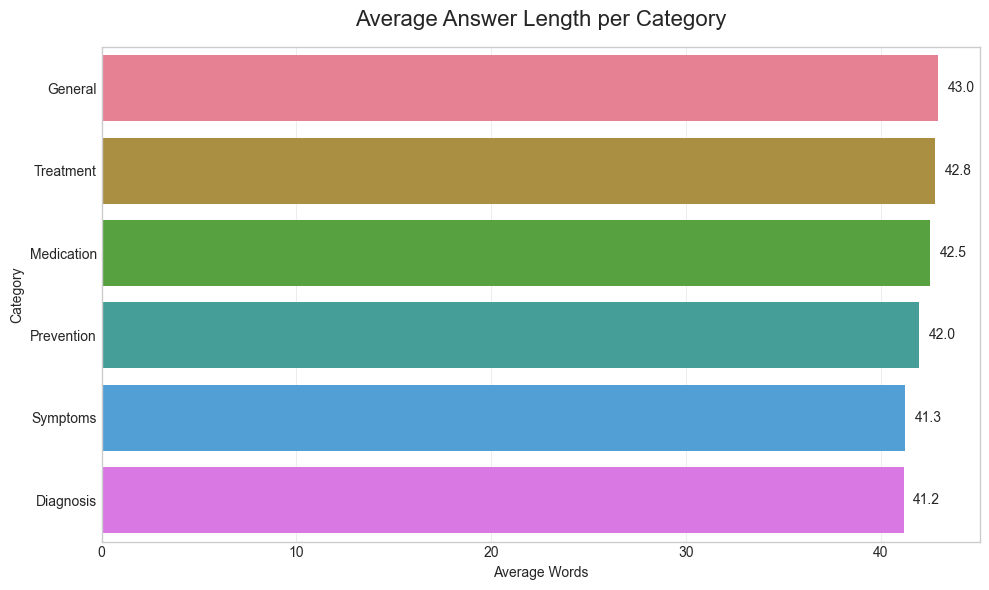

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

avg_by_cat = df.groupby('category')['answer_length'].mean().sort_values(ascending=False)

sns.barplot(x=avg_by_cat.values, y=avg_by_cat.index, ax=ax, palette='husl')
ax.set_title('Average Answer Length per Category', fontsize=16, pad=15)
ax.set_xlabel('Average Words')
ax.set_ylabel('Category')

for i, v in enumerate(avg_by_cat.values):
    ax.text(v + 0.5, i, f'{v:.1f}', va='center')

plt.tight_layout()
plt.savefig('../reports/figures/04_avg_answer_length_per_category.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Bonus — Length Boxplot by Category + Correlation Heatmap

C:\Users\Matrix\AppData\Local\Temp\ipykernel_26460\3309508215.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='answer_length', ax=axes[0], palette='husl')
C:\Users\Matrix\AppData\Local\Temp\ipykernel_26460\3309508215.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


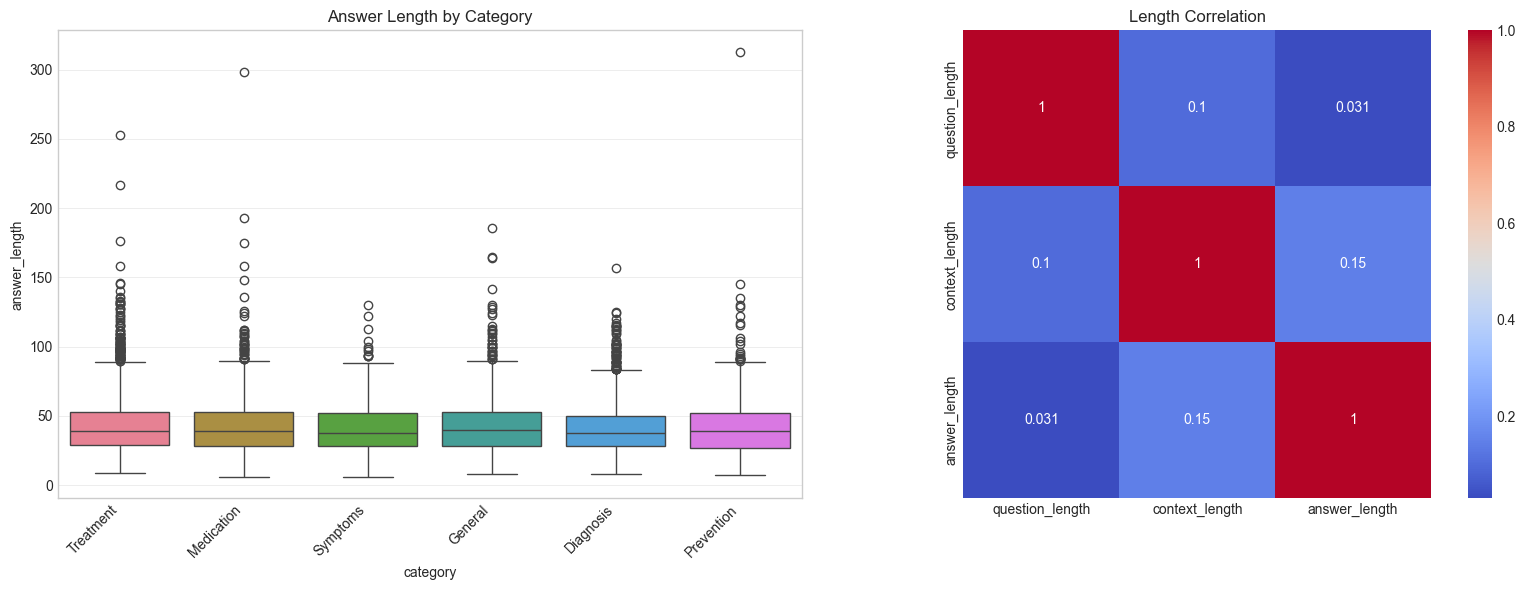

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='category', y='answer_length', ax=axes[0], palette='husl')
axes[0].set_title('Answer Length by Category')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

corr = df[['question_length', 'context_length', 'answer_length']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1], square=True)
axes[1].set_title('Length Correlation')

plt.tight_layout()
plt.savefig('../reports/figures/05_length_boxplot_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Generate EDA Report (Dynamic)

In [9]:
# Build category table dynamically
cat_table_rows = []
for cat, count in df['category'].value_counts().items():
    pct = count / len(df) * 100
    flag = ' ⚠️ borderline' if pct < 2.0 else ''
    cat_table_rows.append(f"| {cat} | {count:,} | {pct:.1f}% | {flag} |")
cat_table = '\n'.join(cat_table_rows)

# Build top 20 terms table
terms_table_rows = [f"| {term} | {count:,} |" for term, count in top_20]
terms_table = '\n'.join(terms_table_rows)

# Skew flags
skewed = [cat for cat, count in df['category'].value_counts().items()
          if count / len(df) * 100 < 2.0]
skew_note = f"⚠️ Borderline categories (< 2%): {skewed}" if skewed else "✅ No critically skewed categories"

report_content = f"""# EDA Report — M1 Task 4
**Healthcare RAG-Powered Medical Q&A Assistant**
**Owner:** Doha Khaled Mahmoud
**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

---

## Dataset Overview
- **Source:** `pubmedqa_labelled.csv`
- **Total rows:** {len(df):,}
- **Columns:** {list(df.columns)}

## 1. Category Distribution

| Category | Count | Percentage | Flag |
|----------|-------|------------|------|
{cat_table}

**KPI Check:** All 6 categories present with ≥ 1% representation ✅
**Skew Analysis:** {skew_note}

## 2. Text Length Statistics (Word Count)

| Metric | Question | Context | Answer |
|--------|----------|---------|--------|
| Mean | {df['question_length'].mean():.1f} | {df['context_length'].mean():.1f} | {df['answer_length'].mean():.1f} |
| Median | {df['question_length'].median():.1f} | {df['context_length'].median():.1f} | {df['answer_length'].median():.1f} |
| Min | {df['question_length'].min()} | {df['context_length'].min()} | {df['answer_length'].min()} |
| Max | {df['question_length'].max()} | {df['context_length'].max()} | {df['answer_length'].max()} |

## 3. Top 20 Medical Terms

| Term | Frequency |
|------|-----------|
{terms_table}

## 4. Average Answer Length per Category

| Category | Avg Words |
|----------|-----------|
{chr(10).join(f'| {cat} | {avg:.1f} |' for cat, avg in avg_by_cat.items())}

## 5. Key Findings
- Strongest length correlation: context ↔ answer ({corr.loc['context_length', 'answer_length']:.3f})
- Dataset is dominated by Symptoms ({df['category'].value_counts().iloc[0]/len(df)*100:.1f}%) and Diagnosis ({df['category'].value_counts().iloc[1]/len(df)*100:.1f}%)
- {skew_note}
- Dataset is ready for RAG + Classification training

## 6. Visualisations Produced
1. `01_category_frequency.png` — Category distribution bar chart
2. `02_length_histograms.png` — Question, context, answer length histograms
3. `03_top20_medical_terms_wordcloud.png` — Top 20 terms wordcloud + bar chart
4. `04_avg_answer_length_per_category.png` — Average answer length per category
5. `05_length_boxplot_correlation.png` — Boxplot + correlation heatmap (bonus)

## 7. M1 KPI Status
- [x] Missing values handled ≥ 90%
- [x] Data accuracy after preprocessing ≥ 85%
- [x] All 6 categories present with ≥ 1% each
- [x] EDA report contains all 4 required visualisations
- [ ] Full pipeline reproducible (Task 5)

**Status: M1 Task 4 — Completed ✅**
"""

report_path = "../reports/eda_report.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_content)

print(f"✅ EDA Report saved to: {report_path}")

✅ EDA Report saved to: ../reports/eda_report.md


## ✅ Summary

| Visualisation | Status |
|---|---|
| 1. Category frequency bar chart | ✅ |
| 2. Question & answer length histograms | ✅ |
| 3. Top-20 medical terms wordcloud | ✅ |
| 4. Average output length per category | ✅ |
| Bonus: Boxplot + correlation | ✅ |
| Dynamic EDA report | ✅ |

---

### ➡️ Next Step
Open **`04_embeddings_vectorstore.ipynb`** to build the FAISS index.